---

# Linear Regressioin Practice

**Dataset : Beer dataset with information about the foam height (in cm) from 3 brands of beer over 15 measurement times (in seconds) after the time of pour.**

In [5]:
import pandas as pd

beer_data = pd.read_csv('beer_foam.csv')

beer_data

,Time,Erdinger,Augustinerbrau,Budweiser
0,0,17.0,14.0,14.0
1,15,16.1,11.8,12.1
2,30,14.9,10.5,10.9
3,45,14.0,9.3,10.0
4,60,13.2,8.5,9.3
5,75,12.5,7.7,8.6
6,90,11.9,7.1,8.0
7,105,11.2,6.5,7.5
8,120,10.7,6.0,7.0
9,150,9.7,5.3,6.2


**Devide the dataset as a Training set(first 12) and Test set(last 3)**

In [6]:
x_train = beer_data['Time'].to_numpy()[:12]
x_test  = beer_data['Time'].to_numpy()[12:]

# Note that t_train and t_test contain 3 target vectors. 
# You should build a mapper function to predict 1 target vector at a time.
t_train = beer_data.drop('Time', axis=1).iloc[:12]
t_test  = beer_data.drop('Time', axis=1).iloc[12:]

In [7]:
x_train

array([  0,  15,  30,  45,  60,  75,  90, 105, 120, 150, 180, 210])

In [8]:
x_test

array([240, 300, 360])

In [9]:
t_train

,Erdinger,Augustinerbrau,Budweiser
0,17.0,14.0,14.0
1,16.1,11.8,12.1
2,14.9,10.5,10.9
3,14.0,9.3,10.0
4,13.2,8.5,9.3
5,12.5,7.7,8.6
6,11.9,7.1,8.0
7,11.2,6.5,7.5
8,10.7,6.0,7.0
9,9.7,5.3,6.2


In [10]:
t_test

,Erdinger,Augustinerbrau,Budweiser
12,7.5,2.9,3.5
13,6.3,1.3,2.0
14,5.2,0.7,0.9


**Mapper function of the form:**

$$y(x) = \exp\left(\sum_{j=0}^M w_jx^j\right) = \exp (\mathbf{X}\mathbf{w})$$

**1. For each brand, train a mapper function with $M=2$ using the training data. Plot the model prediction.**

In [162]:
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
def mapperfunction(x, t, M):
    
    X = np.array([x**i for i in range(M+1)]).T
    
    w = np.linalg.inv(X.T@X)@X.T@t
    
    y = X@w
    
    return w, y

In [36]:
t_train_erdinger= t_train.to_numpy()[:,0]
t_train_erdinger

array([17. , 16.1, 14.9, 14. , 13.2, 12.5, 11.9, 11.2, 10.7,  9.7,  8.9,
        8.3])

In [37]:
t_train_aug = t_train.to_numpy()[:,1]
t_train_aug

array([14. , 11.8, 10.5,  9.3,  8.5,  7.7,  7.1,  6.5,  6. ,  5.3,  4.4,
        3.5])

In [38]:
t_train_bud = t_train.to_numpy()[:,2]
t_train_bud

array([14. , 12.1, 10.9, 10. ,  9.3,  8.6,  8. ,  7.5,  7. ,  6.2,  5.5,
        4.5])

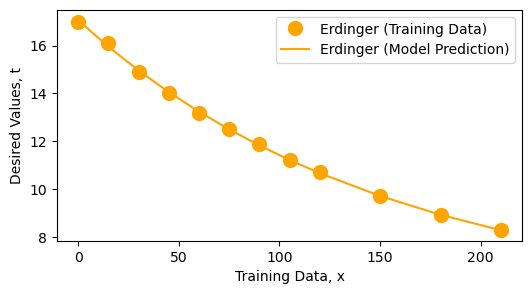

In [60]:
M = 2

w_erdinger, y_train_erdinger_log = mapperfunction(x_train, np.log(t_train_erdinger), M) 
y_train_erdinger = np.exp(y_train_erdinger_log)

plt.figure(figsize=(6,3))
plt.plot(x_train, t_train_erdinger, 'o', color='orange', markersize='10', label='Erdinger (Training Data)')
plt.plot(x_train, y_train_erdinger, '-', color='orange', label='Erdinger (Model Prediction)')

plt.legend()
plt.xlabel('Training Data, x')
plt.ylabel('Desired Values, t');

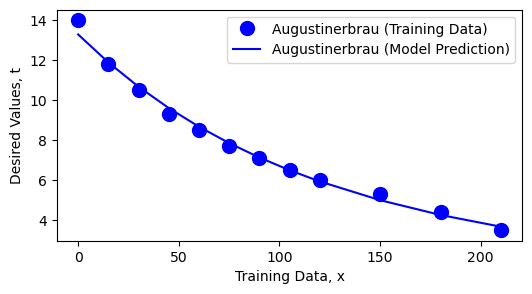

In [61]:
M = 2

w_aug, y_train_aug_log = mapperfunction(x_train, np.log(t_train_aug), M) 
y_train_aug = np.exp(y_train_aug_log)

plt.figure(figsize=(6,3))
plt.plot(x_train, t_train_aug, 'o', color='blue', markersize='10', label='Augustinerbrau (Training Data)')
plt.plot(x_train, y_train_aug, '-', color='blue', label='Augustinerbrau (Model Prediction)')

plt.legend()
plt.xlabel('Training Data, x')
plt.ylabel('Desired Values, t');

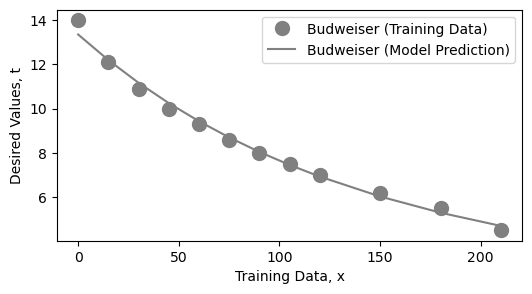

In [62]:
M = 2

w_bud, y_train_bud_log = mapperfunction(x_train, np.log(t_train_bud), M) 
y_train_bud = np.exp(y_train_bud_log)

plt.figure(figsize=(6,3))
plt.plot(x_train, t_train_bud, 'o', color='grey', markersize='10', label='Budweiser (Training Data)')
plt.plot(x_train, y_train_bud, '-', color='grey', label='Budweiser (Model Prediction)')

plt.legend()
plt.xlabel('Training Data, x')
plt.ylabel('Desired Values, t');

**2. Use each trained model to make predictions for the test data.**

In [44]:
def mapperfunction_test(x_test, w):
    
    X = np.array([x_test**i for i in range(len(w))]).T
    
    y = X@w
    
    return y

In [51]:
t_test_erdinger = t_test.to_numpy()[:,0]
t_test_aug = t_test.to_numpy()[:,1]
t_test_bud = t_test.to_numpy()[:,2]

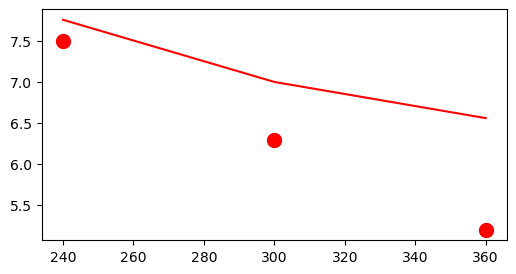

In [63]:
y_test_erdinger_log = mapperfunction_test(x_test, w_erdinger)
y_test_erdinger = np.exp(y_test_erdinger_log)

plt.figure(figsize=(6,3))

plt.plot(x_test, t_test_erdinger, 'o', color='red', markersize='10', label='Erdinger (Test Data)')
plt.plot(x_test, y_test_erdinger, '-', color='red', label='Erdinger (Model Prediction)')

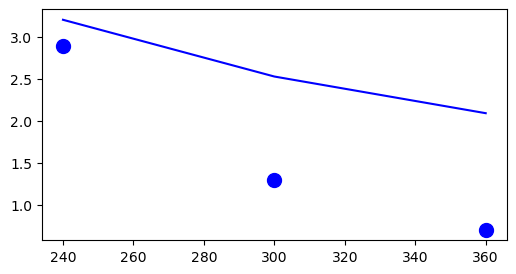

In [64]:
y_test_aug_log = mapperfunction_test(x_test, w_aug)
y_test_aug = np.exp(y_test_aug_log)

plt.figure(figsize=(6,3))

plt.plot(x_test, t_test_aug, 'o', color='blue', markersize='10', label='Augustinerbrau (Test Data)')
plt.plot(x_test, y_test_aug, '-', color='blue', label='Augustinerbrau (Model Prediction)')

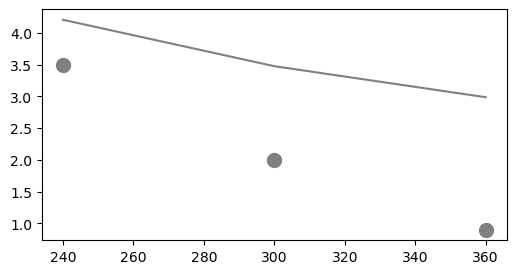

In [65]:
y_test_bud_log = mapperfunction_test(x_test, w_bud)
y_test_bud = np.exp(y_test_bud_log)

plt.figure(figsize=(6,3))

plt.plot(x_test, t_test_bud, 'o', color='grey', markersize='10', label='Budweiser (Test Data)')
plt.plot(x_test, y_test_bud, '-', color='grey', label='Budweiser (Model Prediction)')

**3. For each brand, predict foam height at $t=450$ seconds.**

In [56]:
x_new = np.array([450])

In [66]:
y_new_test_erdinger_log = mapperfunction_test(x_new, w_erdinger)
y_new_test_erdinger = np.exp(y_new_test_erdinger_log)
y_new_test_erdinger

array([6.38604968])

In [67]:
y_new_test_aug_log = mapperfunction_test(x_new, w_aug)
y_new_test_aug = np.exp(y_new_test_aug_log)
y_new_test_aug

array([1.7186533])

In [68]:
y_new_test_bud_log = mapperfunction_test(x_new, w_bud)
y_new_test_bud = np.exp(y_new_test_bud_log)
y_new_test_bud

array([2.56057419])